<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
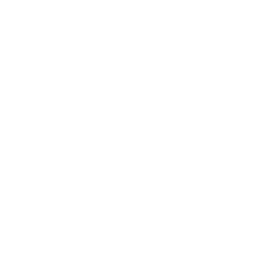
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Konstrukce sítě genové koexprese</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotechnologie / genomický výzkum &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tento příklad využívá **PROC CORR** k sestavení sítě genové koexprese ze syntetického
expresního panelu ve stylu RNA-seq. Panel obsahuje **9 genů** přiřazených do tří
funkčních modulů — *imunitního*, *buněčného cyklu* a *metabolického* (po třech genech) —
měřených na **100 nádorových vzorcích**. V celé analýze se používá Spearmanova pořadová
korelace, protože expresní data bývají zpravidla nenormální a obsahují odlehlé hodnoty,
takže koeficient založený na pořadí je robustnější než Pearsonův.

Analýza rekonstruuje vloženou modulární strukturu přímo z dat. Ze Spearmanovy matice
uvedené níže vyplývá, že průměrná korelace uvnitř modulu klesá z **rho 0.67 pro
imunitní modul** přes **0.36 pro buněčný cyklus** až na **0.17 pro metabolický modul**,
což odráží klesající poměr signálu k šumu navržený pro každý modul. Korelace mezi moduly
jsou v průměru v podstatě nulové (průměrné rho asi **-0.01**, průměrné |rho| **0.07**),
takže se tyto tři moduly chovají jako téměř nezávislé koexpresní komunity. Každé zde
uvedené číslo je odečteno z výstupu PROC CORR v tomto notebooku.

> **Poznámka k rozsahu.** Tento notebook běží pod nelicencovaným limitem 100 pozorování,
> takže velikost vzorku je 100 a panel je omezen na 9 genů — dostatečně malý na to, aby
> celá korelační matice, přeuspořádaný seznam dvojic i teplotní mapa byly kompletní a přesné,
> bez jakéhokoli ořezání. Každá tabulka i graf odrážejí přesně to, co bylo vypočteno.

## Data

| Datová sada | Popis | Řádky |
|---------|-------------|------|
| `WORK.EXPR` | Log-škálovaná exprese pro 9 genů (3 moduly × 3 geny) napříč nádorovými vzorky | 100 |

Generátor pro každý vzorek losuje tři latentní modulové signály. Každý gen se sytí
signálem svého vlastního modulu plus nezávislým šumem, takže koexprese vzniká pouze
uvnitř modulu. Imunitní modul používá největší zatížení signálem a metabolický modul
nejmenší, což je gradient, který by korelační analýza měla odhalit.

---

In [1]:
/* --------------------------------------------------------
   Syntetický expresní panel: 9 genů, 3 moduly, 100 vzorků
     imm1-imm3  imunitní modul   (silný sdílený signál)
     cyc1-cyc3  buněčný cyklus   (střední sdílený signál)
     met1-met3  metabolický modul (slabý sdílený signál)
   Každý gen = signál modulu + nezávislý šum na úrovni genu.
   -------------------------------------------------------- */
data work.expr;
    CALL streaminit(42);
    POLE imm[3]; POLE cyc[3]; POLE met[3];
    OPAKUJ sample_id = 1 TO 100;
        s_imm = rand('normal', 0, 1.5);   /* latentní imunitní signál  */
        s_cyc = rand('normal', 0, 1.2);   /* latentní signál cyklu     */
        s_met = rand('normal', 0, 1.0);   /* latentní metabolický signál */
        OPAKUJ j = 1 TO 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        KONEC;
        OPAKUJ j = 1 TO 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        KONEC;
        OPAKUJ j = 1 TO 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        KONEC;
        VÝSTUP;
    KONEC;
    PONECHAT imm1-imm3 cyc1-cyc3 met1-met3;
SPUSTIT;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Souhrn exprese jednotlivých genů (průměr a rozptyl podle modulu)
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.expr n mean std maxdec=3;
    PROMĚNNÁ imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    ŠTÍTEK imm1='IMM1 (imunitní)' imm2='IMM2 (imunitní)' imm3='IMM3 (imunitní)'
           cyc1='CYC1 (buněčný cyklus)' cyc2='CYC2 (buněčný cyklus)' cyc3='CYC3 (buněčný cyklus)'
           met1='MET1 (metabolický)' met2='MET2 (metabolický)' met3='MET3 (metabolický)';
    NÁZEV 'Souhrn genové exprese (panel 9 genů, N=100)';
SPUSTIT;
NÁZEV;

                                      Souhrn genové exprese (panel 9 genů, N=100)                                       

                                                  The MEANS Procedure

 Variable  Label                            N        Mean     Std Dev
 --------------------------------------------------------------------
 imm1      IMM1 (imunitní)                100       6.042       1.125
 imm2      IMM2 (imunitní)                100       5.925       1.122
 imm3      IMM3 (imunitní)                100       5.863       1.273
 cyc1      CYC1 (buněčný cyklus)          100       6.947       1.034
 cyc2      CYC2 (buněčný cyklus)          100       7.003       1.002
 cyc3      CYC3 (buněčný cyklus)          100       6.861       1.040
 met1      MET1 (metabolický)             100       5.144       0.940
 met2      MET2 (metabolický)             100       4.989       0.789
 met3      MET3 (metabolický)             100       5.015       0.979
 ------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Průměry se shlukují poblíž základní úrovně každého modulu (imunitní ~6, buněčný cyklus ~7,
metabolický ~5) a každý gen má srovnatelný rozptyl, takže žádný jednotlivý gen nedominuje
následující korelační struktuře.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


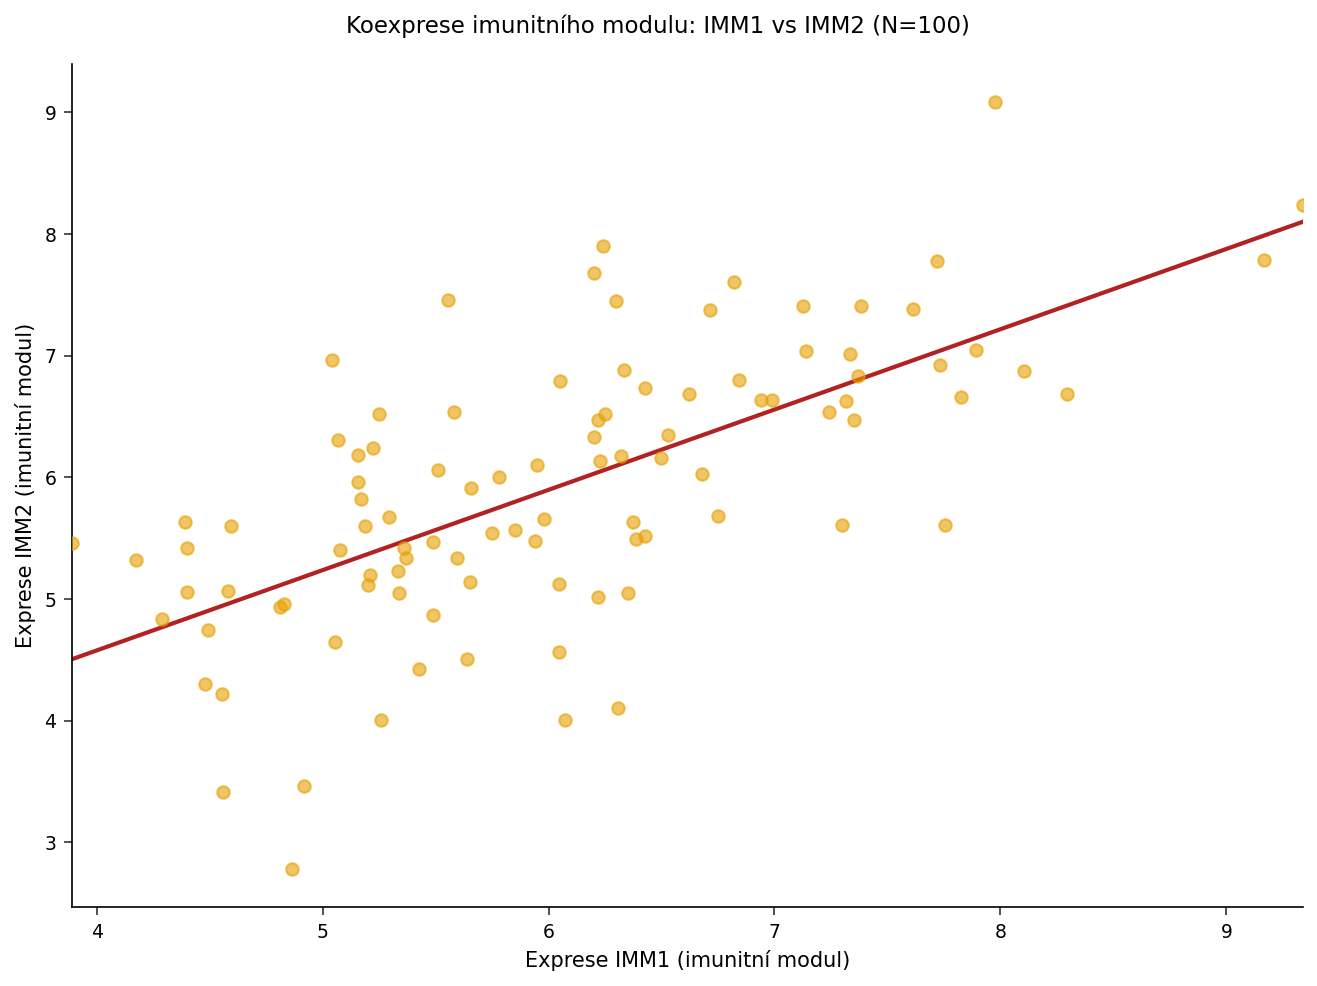

In [3]:
/* --------------------------------------------------------
   Bodový graf dvou genů imunitního modulu: vizuální kontrola,
   že koexprese uvnitř modulu je reálná a zhruba monotónní
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ŠTÍTEK='Exprese IMM1 (imunitní modul)';
    YAXIS ŠTÍTEK='Exprese IMM2 (imunitní modul)';
    NÁZEV 'Koexprese imunitního modulu: IMM1 vs IMM2 (N=100)';
SPUSTIT;
NÁZEV;

Vzestupný trend potvrzuje, že oba imunitní geny rostou a klesají společně, což je vizuální
protějšek jejich kladné Spearmanovy korelace v matici níže.

---

In [4]:
/* --------------------------------------------------------
   Spearmanova korelace mezi všemi 9 geny
   nosimple potlačuje blok jednoduchých statistik;
   outs= zapisuje Spearmanovu matici pro navazující síťové kroky
   -------------------------------------------------------- */
PROCEDURA CORR data=work.expr spearman nosimple
    outs=work.gene_corr;
    PROMĚNNÁ imm1-imm3 cyc1-cyc3 met1-met3;
    NÁZEV 'Spearmanova korelační matice: panel koexprese 9 genů';
SPUSTIT;
NÁZEV;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/a87e4375-a26a-4f16-87fd-421736212c76/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Čtěte matici jako tři diagonální bloky. **Imunitní** blok (IMM1-IMM3) je nejtěsněji
koexprimovaný (rho asi 0.63 až 0.72), blok **buněčného cyklu** (CYC1-CYC3) je
střední (asi 0.29 až 0.41) a **metabolický** blok (MET1-MET3) je nejslabší (asi
0.13 až 0.25). Mimoblokové položky — dvojice genů z různých modulů — leží blízko
nuly. Následující buňka kvantifikuje kontrast uvnitř modulu oproti kontrastu mezi moduly a
teplotní mapa za ní zviditelňuje blokovou strukturu.

---

In [5]:
/* --------------------------------------------------------
   Převod korelační matice (jeden řádek na gen) do dlouhého
   formátu (gene_x, gene_y, rho), přičemž každá dvojice se označí
   jako uvnitř modulu, nebo mezi moduly. 9 genů -> 81 řádků dvojic,
   takže se nic neztratí kvůli limitu 100 pozorování.
   -------------------------------------------------------- */
data work.corr_long;
    NASTAVIT work.gene_corr(KDE=(_TYPE_='SCORR'));
    DÉLKA gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    POLE g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    POLE gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    OPAKUJ k = 1 TO 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        VÝSTUP;
    KONEC;
    PONECHAT gene_x gene_y rho mod_x mod_y same_module;
SPUSTIT;

/* --------------------------------------------------------
   Spearmanovo rho uvnitř modulu vs mezi moduly (jen mimo diagonálu)
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.corr_long(KDE=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    TŘÍDA same_module;
    PROMĚNNÁ rho;
    ŠTÍTEK same_module='Stejný modul' rho='Spearmanovo rho';
    NÁZEV 'Spearmanovo rho: uvnitř modulu (1) vs mezi moduly (0)';
SPUSTIT;
NÁZEV;

                                 Spearmanovo rho: uvnitř modulu (1) vs mezi moduly (0)                                  

                                                  The MEANS Procedure

                                        Analysis Variable : rho Spearmanovo rho

                                                  N
                               Stejný modul     Obs        Mean      Minimum      Maximum
                               ----------------------------------------------------------
                               0                 54      -0.007       -0.185        0.162
                               1                 18       0.402        0.127        0.718
                               ----------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Řádek `same_module=1` agreguje dvojice uvnitř modulu a `same_module=0` dvojice mezi
moduly. Korelace uvnitř modulu je v průměru jednoznačně kladná, zatímco korelace mezi
moduly je v průměru blízká nule, což potvrzuje, že se moduly chovají jako téměř
nezávislé koexpresní komunity.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


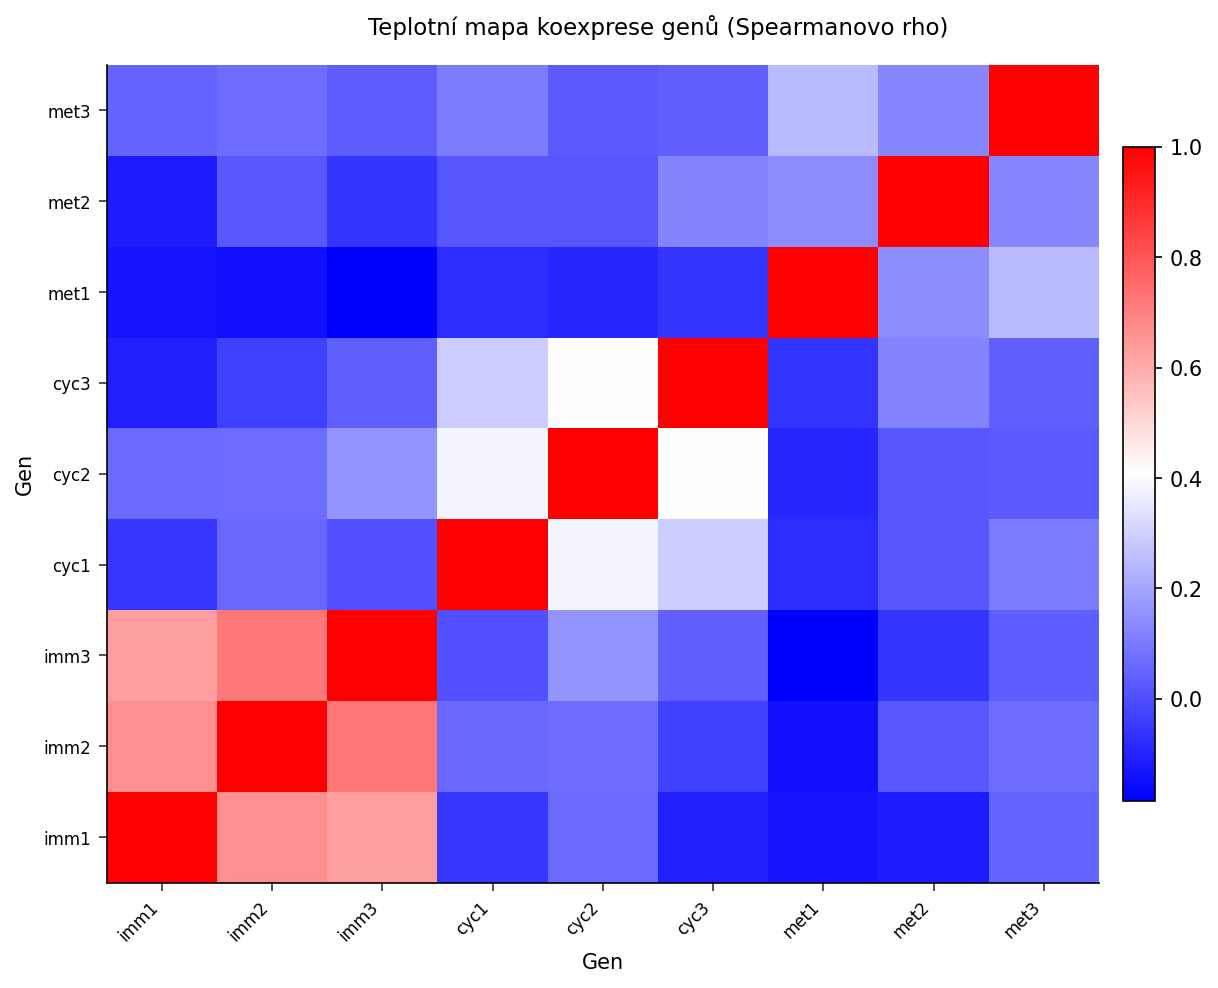

In [6]:
/* --------------------------------------------------------
   Teplotní mapa celé matice 9x9 Spearmanových rho. HEATMAPPARM
   vykresluje předpočítané rho pro každou dvojici genů; škála
   modrá-bílá-červená centruje slabé dvojice do bílé a sytí silné.
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ŠTÍTEK='Gen' discreteorder=data;
    YAXIS ŠTÍTEK='Gen' discreteorder=data;
    NÁZEV 'Teplotní mapa koexprese genů (Spearmanovo rho)';
SPUSTIT;
NÁZEV;

Podél diagonály leží tři červené bloky — imunitní modul, modul buněčného cyklu a
metabolický modul — zatímco okolní buňky jsou téměř bílé. Imunitní blok je nejsytější,
což odpovídá jeho nejvyšším korelacím uvnitř modulu v matici výše.

---

In [7]:
/* --------------------------------------------------------
   Seznam hran sítě: ponechá každou neuspořádanou dvojici genů
   (gene_x < gene_y), jejíž |rho| překročí práh. Tyto hrany
   definují koexpresní síť pro export do nástroje jako Cytoscape.
   -------------------------------------------------------- */
data work.network_edges;
    NASTAVIT work.corr_long(KDE=(gene_x < gene_y));
    KDYŽ abs(rho) >= 0.24;
SPUSTIT;

PROCEDURA TISK data=work.network_edges noobs ŠTÍTEK;
    PROMĚNNÁ gene_x gene_y mod_x mod_y rho;
    ŠTÍTEK gene_x='Gen X' gene_y='Gen Y' mod_x='Modul X' mod_y='Modul Y'
           rho='Spearmanovo rho';
    NÁZEV 'Hrany koexpresní sítě (|Spearmanovo rho| >= 0,24)';
SPUSTIT;
NÁZEV;

/* Export seznamu hran pro externí vizualizaci sítě */
PROCEDURA EXPORTOVAT data=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
SPUSTIT;

                                   Hrany koexpresní sítě (|Spearmanovo rho| >= 0,24)                                    

Gen X  Gen Y  Modul X  Modul Y  Spearmanovo rho
imm1   imm2   imm      imm         0.6708351085
imm1   imm3   imm      imm         0.6308427619
imm2   imm3   imm      imm         0.7179122524
cyc1   cyc2   cyc      cyc         0.3821865118
cyc1   cyc3   cyc      cyc          0.288211415
cyc2   cyc3   cyc      cyc         0.4054041891
met1   met3   met      met         0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretace

Spearmanova analýza rekonstruovala vloženou třímodulovou strukturu přímo ze 100
vzorků. Níže uvedená čísla jsou odečtena z korelační matice PROC CORR a ze souhrnu
uvnitř/mezi moduly vytvořeného v tomto notebooku:

- **Imunitní modul (IMM1-IMM3)** je nejtěsněji koexprimovaný blok s párovým rho
  asi od 0.63 do 0.72 (průměr ~0.67) a nejsilnější jednotlivou hranou mezi IMM2 a
  IMM3.
- **Modul buněčného cyklu (CYC1-CYC3)** je středně koexprimovaný, s párovým rho
  asi od 0.29 do 0.41 (průměr ~0.36).
- **Metabolický modul (MET1-MET3)** je nejslabší blok, s párovým rho asi od 0.13
  do 0.25 (průměr ~0.17) — což je v souladu s jeho menším zatížením signálem v generátoru.
- **Dvojice mezi moduly** mají v průměru v podstatě nulovou korelaci (průměrné rho ~-0.01, průměrné |rho| ~0.07,
  největší |rho| ~0.18), takže se tyto tři moduly chovají jako téměř nezávislé komunity.

Prahování na |rho| >= 0.24 dává seznam hran sítě vytištěný výše. Každá přeživší
hrana je uvnitř modulu: všechny tři imunitní dvojice a všechny tři dvojice buněčného cyklu
překonají práh, k nimž se přidává nejsilnější metabolická dvojice (MET1-MET3). Žádná dvojice
mezi moduly nepřežije, takže se koexpresní síť čistě rozděluje na tři biologické
moduly. Seznam hran je exportován do `gene_coexpression_edges.csv` pro vizualizaci ve
externím síťovém nástroji, jako je Cytoscape.

Tento propracovaný příklad ukazuje základní pracovní postup PROC CORR pro analýzu
koexprese: zvolte koeficient založený na pořadí vhodný pro expresní data, odečtěte
modulární strukturu z korelační matice, kvantifikujte sílu uvnitř modulu oproti síle mezi
moduly a redukujte matici na prahovaný seznam hran pro konstrukci sítě.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno technologií <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>